# Parameter Sensitivity Analysis

Drop-by-drop 적분의 결과는 **두 가지 핵심 파라미터**에 크게 의존합니다.

| Parameter | 역할 | 영향 |
|-----------|------|------|
| **tolerance_ppm** | XIC 추출 시 m/z 윈도우 폭 | 너무 좁으면 신호 손실, 너무 넓으면 간섭 포함 |
| **half_window** | 각 drop center 전후 적분 범위 (초) | 너무 좁으면 spike 잘림, 너무 넓으면 인접 drop 겹침 |

이 노트북에서는 각 파라미터를 변화시키면서 **drop별 면적과 RSD%**에 미치는 영향을 분석합니다.
최적 파라미터 = **면적이 안정적이고 RSD%가 최소**인 지점입니다.

In [ ]:
!pip install -q pyopenms scipy matplotlib numpy pandas openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy import integrate
import pyopenms as oms
import openpyxl, os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

### 데이터 로드 및 XIC 추출
mzML 데이터를 로드하고 화합물별 XIC를 추출합니다.

In [ ]:
# === 데이터 로드 ===
DATA_DIR = 'echo-tof-colab/data'
MZML_DIR = f'{DATA_DIR}/mzml'
TOFMS_FILE = f'{MZML_DIR}/20260330_TOFMS.mzML'
MRMHR_FILE = f'{MZML_DIR}/20260330_MRMHR_Q1Q3_Final.mzML'
EXCEL_FILE = f'{DATA_DIR}/Explosives_EchoMS_20260331.xlsx'

def load_mzml(filepath):
    """mzML 파일을 로드하여 MSExperiment 객체 반환"""
    exp = oms.MSExperiment()
    oms.MzMLFile().load(filepath, exp)
    print(f'로드 완료: {os.path.basename(filepath)} ({exp.getNrSpectra()} spectra)')
    return exp

exp_tof = load_mzml(TOFMS_FILE)

def extract_tic(exp, ms_level=1):
    """TIC 추출"""
    rt_list, tic_list = [], []
    for spec in exp:
        if spec.getMSLevel() == ms_level:
            rt_list.append(spec.getRT() / 60.0)
            mz, intensity = spec.get_peaks()
            tic_list.append(np.sum(intensity))
    return np.array(rt_list), np.array(tic_list)

rt_tof, tic_tof = extract_tic(exp_tof)

def extract_xic(exp, target_mz, tolerance_ppm=20.0, ms_level=1):
    """XIC 추출: target_mz ± tolerance 범위의 intensity 합"""
    rt_list, int_list = [], []
    tol = target_mz * tolerance_ppm * 1e-6
    for spec in exp:
        if spec.getMSLevel() == ms_level:
            rt_list.append(spec.getRT() / 60.0)
            mz, ints = spec.get_peaks()
            mask = (mz >= target_mz - tol) & (mz <= target_mz + tol)
            int_list.append(float(ints[mask].sum()) if mask.any() else 0.0)
    return np.array(rt_list), np.array(int_list)

# 화합물 스킴 로드
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws_std = wb['STD list']
compounds = []
for row in ws_std.iter_rows(min_row=2, max_row=16, values_only=True):
    if row[0] and row[1]:
        compounds.append({'name': str(row[2] or row[1]), 'full_name': str(row[1]), 'mz': None})

# XIC 추출
target_compounds = {
    'TNT': {'mz': 226.009, 'adduct': '[M-H]-'},
    'RDX': {'mz': 281.048, 'adduct': '[M+CH3COO]-'},
    'HMX': {'mz': 355.0592, 'adduct': '[M+CH3COO]-'},
    '2,4-DNT': {'mz': 181.0124, 'adduct': '[M-H]-'},
    'Tetryl': {'mz': 241.0204, 'adduct': '[M-NO2]-'},
    '4-Am-DNT': {'mz': 196.0358, 'adduct': '[M-H]-'},
    '2,6-DNT': {'mz': 182.018, 'adduct': '[M]-'},
}

xic_data = {}
for name, info in target_compounds.items():
    rt, intensity = extract_xic(exp_tof, info['mz'])
    xic_data[name] = {'rt': rt, 'intensity': intensity, 'mz': info['mz']}

detected = {k: v for k, v in xic_data.items() if v['intensity'].max() > 0}
print(f'검출된 화합물: {len(detected)}/{len(target_compounds)}')

## 1. tolerance_ppm 감도 분석

- **tolerance_ppm**은 XIC 추출 시 target m/z로부터 양쪽으로 허용하는 질량 오차 범위
- 20 ppm이면 m/z 226에서 ±0.0045 Da
- 값을 변화시키면서 **동일 drop들의 평균 면적과 RSD%** 변화를 관찰

In [ ]:
# tolerance_ppm 감도 분석 (drop-by-drop 기반)
from scipy.signal import find_peaks
from scipy import integrate

ISOTOPE_OFFSETS = [0.0, 1.00335, 2.00671]
test_compound = 'TNT'
test_adducts = [{'name': '[M-H]-', 'mz': 226.009}]
tol_values = [5, 10, 20, 50, 100]
HALF_WINDOW = 0.921  # = 1 scan interval (apex +/- 1 scan)  # fixed

rts_sec = np.array([spec.getRT() for spec in exp_tof if spec.getMSLevel() == 1])

# First: get drop table at default tolerance (20 ppm)
def get_xic(exp, adducts, tol_ppm):
    xic = np.zeros(len(rts_sec))
    for adduct in adducts:
        for iso in ISOTOPE_OFFSETS:
            tmz = adduct['mz'] + iso
            tol = tmz * tol_ppm * 1e-6
            idx = 0
            for spec in exp:
                if spec.getMSLevel() == 1:
                    mzs, ints = spec.get_peaks()
                    mask = (mzs >= tmz - tol) & (mzs <= tmz + tol)
                    if mask.any(): xic[idx] += float(ints[mask].sum())
                    idx += 1
    return xic

# Get common drop table
ref_xic = get_xic(exp_tof, test_adducts, 20)
nonzero = ref_xic[ref_xic > 0]
peaks, _ = find_peaks(ref_xic, height=np.median(nonzero)*3, distance=5)
spike_rts = rts_sec[peaks]
clusters, cur = [], [spike_rts[0]]
for rt in spike_rts[1:]:
    if rt - cur[-1] < 2.0: cur.append(rt)
    else: clusters.append(cur); cur = [rt]
clusters.append(cur)
drops = [{'center_rt': np.mean(cl)} for cl in clusters]
print(f'Reference drops: {len(drops)}')

# Sweep tolerance
results_tol = {}
for tol_ppm in tol_values:
    xic = get_xic(exp_tof, test_adducts, tol_ppm)
    areas = []
    for drop in drops:
        c = drop['center_rt']
        mask = (rts_sec >= c - HALF_WINDOW) & (rts_sec <= c + HALF_WINDOW)
        rw, iw = rts_sec[mask], xic[mask]
        if len(rw) < 4: areas.append(0); continue
        areas.append(integrate.trapezoid(iw, rw))
    nz = [a for a in areas if a > 0]
    m = np.mean(nz) if nz else 0
    rsd = (np.std(nz)/m*100) if (m > 0 and len(nz) > 1) else 0
    results_tol[tol_ppm] = {'mean': m, 'rsd': rsd, 'areas': nz}
    print(f'  tol={tol_ppm:3d} ppm | Mean Area={m:.1f} | RSD={rsd:.1f}% | Drops={len(nz)}')


### tolerance_ppm 결과 시각화

- 왼쪽: tolerance에 따른 평균 면적 변화 (안정화 지점 = 최적)
- 오른쪽: tolerance에 따른 RSD% 변화 (최소 = 최적 재현성)

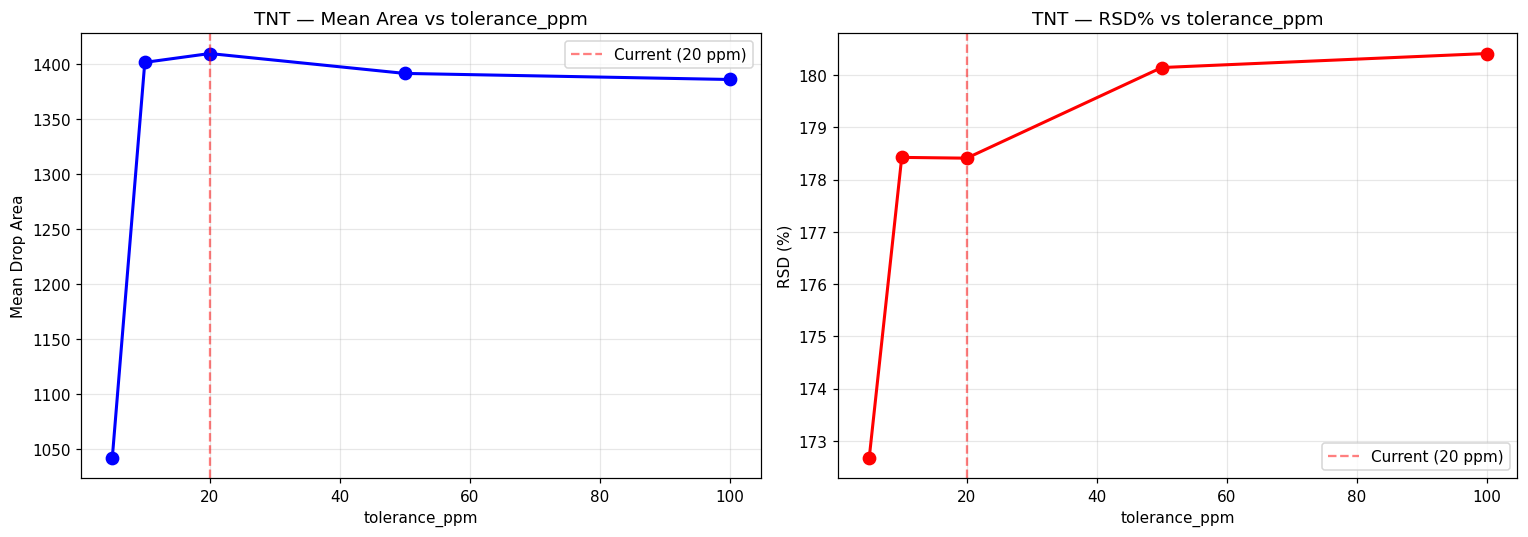

In [1]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tols = list(results_tol.keys())
means = [results_tol[t]['mean'] for t in tols]
rsds_t = [results_tol[t]['rsd'] for t in tols]

ax1.plot(tols, means, 'bo-', linewidth=2)
ax1.set_xlabel('tolerance_ppm')
ax1.set_ylabel('Mean Drop Area')
ax1.set_title(f'{test_compound} — Mean Area vs tolerance_ppm')
ax1.axvline(20, color='red', linestyle='--', alpha=0.5, label='Current (20 ppm)')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(tols, rsds_t, 'ro-', linewidth=2)
ax2.set_xlabel('tolerance_ppm')
ax2.set_ylabel('RSD (%)')
ax2.set_title(f'{test_compound} — RSD% vs tolerance_ppm')
ax2.axvline(20, color='red', linestyle='--', alpha=0.5, label='Current (20 ppm)')
ax2.axhline(20, color='green', linestyle=':', alpha=0.5, label='20% threshold')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 2. half_window 감도 분석

- **half_window**는 각 drop center RT 전후로 적분하는 시간 범위 (초)
- 너무 좁으면 spike의 꼬리를 잘라냄 → 면적 손실
- 너무 넓으면 인접 drop 신호가 겹침 → 면적 과대 + RSD 증가
- tolerance_ppm은 20 ppm으로 고정하고 half_window만 변화

In [ ]:
# half_window 감도 분석
hw_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
xic_ref = get_xic(exp_tof, test_adducts, 20)  # fixed tolerance

results_hw = {}
for hw in hw_values:
    areas = []
    for drop in drops:
        c = drop['center_rt']
        mask = (rts_sec >= c - hw) & (rts_sec <= c + hw)
        rw, iw = rts_sec[mask], xic_ref[mask]
        if len(rw) < 4: areas.append(0); continue
        areas.append(integrate.trapezoid(iw, rw))
    nz = [a for a in areas if a > 0]
    m = np.mean(nz) if nz else 0
    rsd = (np.std(nz)/m*100) if (m > 0 and len(nz) > 1) else 0
    results_hw[hw] = {'mean': m, 'rsd': rsd, 'areas': nz}
    print(f'  hw={hw:.1f}s | Mean Area={m:.1f} | RSD={rsd:.1f}% | Drops={len(nz)}')


### half_window 결과 시각화

- 면적이 안정화되면서 RSD%가 최소인 half_window가 최적

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

hws = list(results_hw.keys())
means_h = [results_hw[h]['mean'] for h in hws]
rsds_h = [results_hw[h]['rsd'] for h in hws]

ax1.plot(hws, means_h, 'bo-', linewidth=2)
ax1.set_xlabel('half_window (sec)')
ax1.set_ylabel('Mean Drop Area')
ax1.set_title(f'{test_compound} — Mean Area vs half_window')
ax1.axvline(1.5, color='red', linestyle='--', alpha=0.5, label='Current (1.5s)')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hws, rsds_h, 'ro-', linewidth=2)
ax2.set_xlabel('half_window (sec)')
ax2.set_ylabel('RSD (%)')
ax2.set_title(f'{test_compound} — RSD% vs half_window')
ax2.axvline(1.5, color='red', linestyle='--', alpha=0.5, label='Current (1.5s)')
ax2.axhline(20, color='green', linestyle=':', alpha=0.5, label='20% threshold')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

| Parameter | 최적 기준 | 현재 값 |
|-----------|----------|--------|
| **tolerance_ppm** | 면적 안정화 + RSD 최소 | 20 ppm |
| **half_window** | spike 포함 + 인접 drop 미포함 | 1.5 sec |

위 그래프에서 면적이 안정화되고 RSD%가 최소인 지점을 선택하면 됩니다.
데이터가 바뀌면 이 분석을 다시 실행하여 파라미터를 재조정해야 합니다.

---

⬅️ **Prev:** [Summation Integration](06%20Summation%20Integration.ipynb) | **Next:** [Relative Ion Abundance](08%20Yield%20Composition.ipynb) ➡️